In [9]:
# import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from si_prefix import si_format
import types

# Set font properties
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['font.weight'] = 'bold'


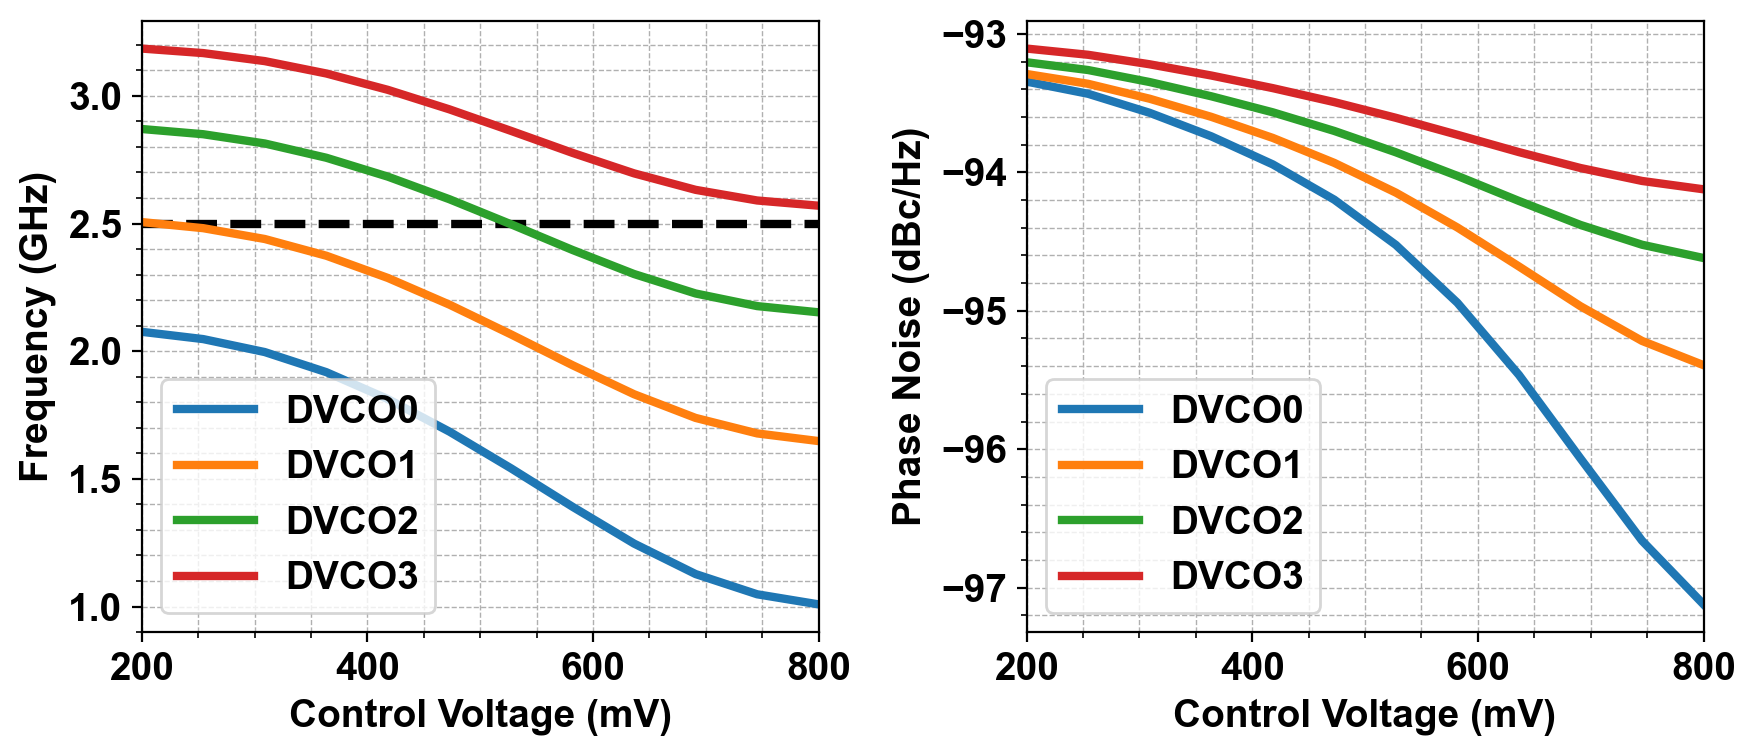

In [2]:
# Import Frequency Sweep Data for DCOs
tmp = sp.io.loadmat('PSS_freq_sweep_tt_60_1p0V.mat')
raw_vctrl = tmp['vctrl'].squeeze()  # Voltage control vector
raw_freq_dco0 = tmp['freq_dco0'].squeeze()  # Frequency offset vector for DCO0
raw_freq_dco1 = tmp['freq_dco1'].squeeze()  # Frequency offset vector for DCO1 
raw_freq_dco2 = tmp['freq_dco2'].squeeze()  # Frequency offset vector for DCO2 
raw_freq_dco3 = tmp['freq_dco3'].squeeze()  # Frequency offset vector for DCO3 

# Interpolate to PLL frequency vector
samples = 100
vctrl = np.linspace(np.min(raw_vctrl), np.max(raw_vctrl), samples)
freq_dco0 = np.interp(vctrl, raw_vctrl, raw_freq_dco0)
freq_dco1 = np.interp(vctrl, raw_vctrl, raw_freq_dco1)
freq_dco2 = np.interp(vctrl, raw_vctrl, raw_freq_dco2)
freq_dco3 = np.interp(vctrl, raw_vctrl, raw_freq_dco3)

# Import Phase Noise Sweep Data for DCOs
tmp = sp.io.loadmat('PSS_pnoise1M_sweep_tt_60_1p0V.mat')
raw_vctrl = tmp['vctrl'].squeeze()  # Voltage control vector
raw_pnoise_dco0 = tmp['pn_dco0'].squeeze()  # Frequency offset vector for DCO0
raw_pnoise_dco1 = tmp['pn_dco1'].squeeze()  # Frequency offset vector for DCO1 
raw_pnoise_dco2 = tmp['pn_dco2'].squeeze()  # Frequency offset vector for DCO2 
raw_pnoise_dco3 = tmp['pn_dco3'].squeeze()  # Frequency offset vector for DCO3 
# Interpolate to PLL frequency vector
pnoise_dco0 = np.interp(vctrl, raw_vctrl, raw_pnoise_dco0)
pnoise_dco1 = np.interp(vctrl, raw_vctrl, raw_pnoise_dco1)
pnoise_dco2 = np.interp(vctrl, raw_vctrl, raw_pnoise_dco2)
pnoise_dco3 = np.interp(vctrl, raw_vctrl, raw_pnoise_dco3)

# Combined plot: Frequency and Phase Noise vs Control Voltage side by side
plt.figure(figsize=(9, 4), dpi=200)

# First subplot: Frequency vs Control Voltage
plt.subplot(1, 2, 1)
plt.minorticks_on()
plt.axhline(y=2.5, color='black', linestyle='--', linewidth=3)
plt.plot(vctrl*1e3, freq_dco0 / 1e9, label='DVCO0', linewidth=3)
plt.plot(vctrl*1e3, freq_dco1 / 1e9, label='DVCO1', linewidth=3)
plt.plot(vctrl*1e3, freq_dco2 / 1e9, label='DVCO2', linewidth=3)
plt.plot(vctrl*1e3, freq_dco3 / 1e9, label='DVCO3', linewidth=3)
plt.xlabel('Control Voltage (mV)', fontweight='bold')
plt.ylabel('Frequency (GHz)', fontweight='bold')
plt.xlim([np.min(vctrl*1e3), np.max(vctrl*1e3)])
plt.legend()
plt.grid(which='both', linestyle='--', linewidth=0.5)

# Second subplot: Phase Noise vs Control Voltage
plt.subplot(1, 2, 2)
plt.minorticks_on()
plt.plot(vctrl*1e3, pnoise_dco0, label='DVCO0', linewidth=3)
plt.plot(vctrl*1e3, pnoise_dco1, label='DVCO1', linewidth=3)
plt.plot(vctrl*1e3, pnoise_dco2, label='DVCO2', linewidth=3)
plt.plot(vctrl*1e3, pnoise_dco3, label='DVCO3', linewidth=3)
plt.xlabel('Control Voltage (mV)', fontweight='bold')
plt.ylabel('Phase Noise (dBc/Hz)', fontweight='bold')
plt.xlim([np.min(vctrl*1e3), np.max(vctrl*1e3)])
plt.legend()
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
#plt.savefig('vco_freq_pn_tt.pdf', dpi=400)
plt.show()




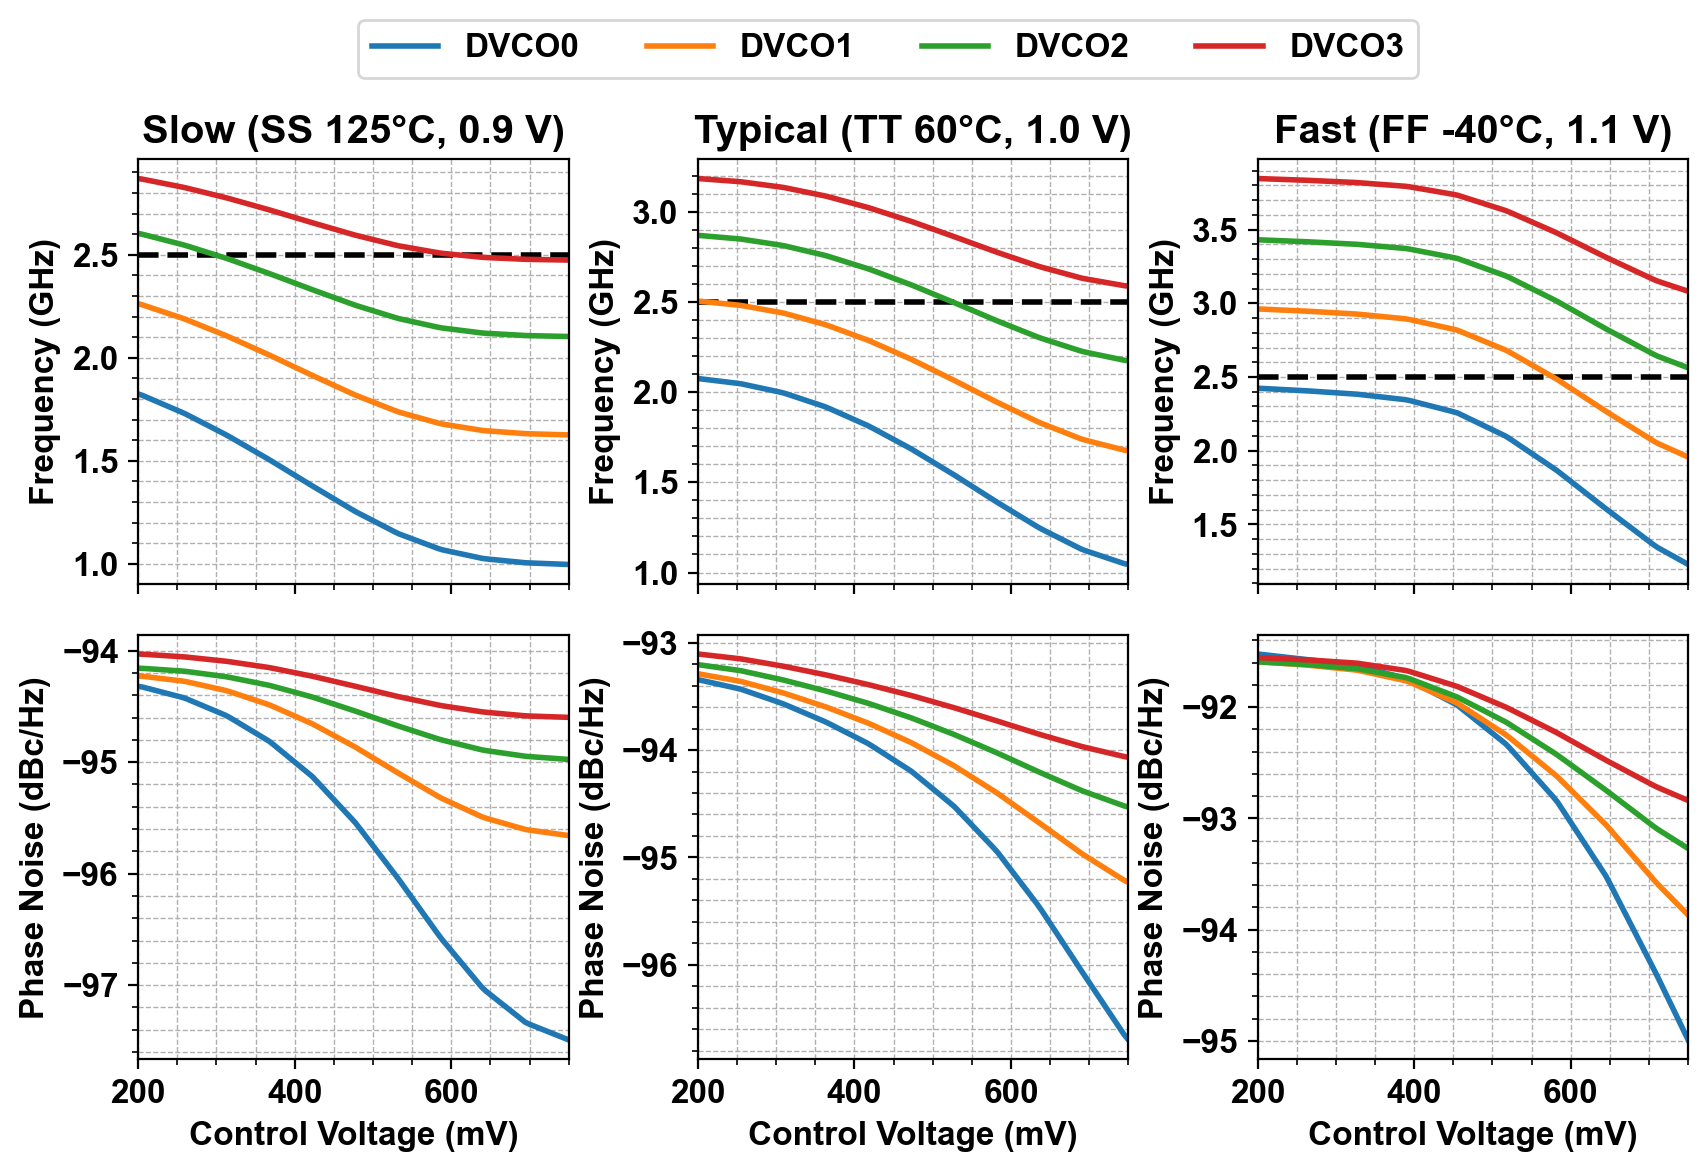

In [17]:
# Comparacion de frecuencia y ruido de fase para SS, TT y FF
corners = {
    'Slow': ('PSS_freq_sweep_ss_125_0p9V.mat', 'PSS_pnoise1M_sweep_ss_125_0p9V.mat', 'SS 125°C, 0.9 V'),
    'Typical': ('PSS_freq_sweep_tt_60_1p0V.mat', 'PSS_pnoise1M_sweep_tt_60_1p0V.mat', 'TT 60°C, 1.0 V'),
    'Fast': ('PSS_freq_sweep_ff_m40_1p1V.mat', 'PSS_pnoise1M_sweep_ff_m40_1p1V.mat', 'FF -40°C, 1.1 V'),
}

corner_data = {}
for corner, (freq_file, pnoise_file, condition) in corners.items():
    freq_data = sp.io.loadmat(freq_file)
    pnoise_data = sp.io.loadmat(pnoise_file)
    corner_data[corner] = {
        'condition': condition,
        'freq_vctrl': freq_data['vctrl'].squeeze(),
        'pnoise_vctrl': pnoise_data['vctrl'].squeeze(),
        'freq': [freq_data[f'freq_dco{i}'].squeeze() for i in range(4)],
        'pnoise': [pnoise_data[f'pn_dco{i}'].squeeze() for i in range(4)],
    }

# Usa el intervalo de voltaje comun para comparar las tres esquinas.
vctrl_min = max(
    np.min(data[key])
    for data in corner_data.values()
    for key in ('freq_vctrl', 'pnoise_vctrl')
)
vctrl_max = min(
    np.max(data[key])
    for data in corner_data.values()
    for key in ('freq_vctrl', 'pnoise_vctrl')
)
vctrl_compare = np.linspace(vctrl_min, vctrl_max, 100)

fig, axes = plt.subplots(2, 3, figsize=(10, 6), dpi=200, sharex=True)
for column, (corner, data) in enumerate(corner_data.items()):
    frequency_ax = axes[0, column]
    phase_noise_ax = axes[1, column]

    frequency_ax.axhline(y=2.5, color='black', linestyle='--', linewidth=2)
    for index in range(4):
        frequency_ax.plot(
            vctrl_compare * 1e3,
            np.interp(vctrl_compare, data['freq_vctrl'], data['freq'][index]) / 1e9,
            label=f'DVCO{index}',
            linewidth=2,
        )
        phase_noise_ax.plot(
            vctrl_compare * 1e3,
            np.interp(vctrl_compare, data['pnoise_vctrl'], data['pnoise'][index]),
            label=f'DVCO{index}',
            linewidth=2,
        )

    frequency_ax.set_title(f'{corner} ({data["condition"]})', fontweight='bold')
    frequency_ax.set_ylabel('Frequency (GHz)', fontweight='bold')
    phase_noise_ax.set_ylabel('Phase Noise (dBc/Hz)', fontweight='bold')
    phase_noise_ax.set_xlabel('Control Voltage (mV)', fontweight='bold')

    for ax in (frequency_ax, phase_noise_ax):
        ax.set_xlim(vctrl_min * 1e3, vctrl_max * 1e3)
        ax.minorticks_on()
        ax.grid(which='both', linestyle='--', linewidth=0.5)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.99), ncol=4)
fig.subplots_adjust(top=0.86, hspace=0.12, wspace=0.3)
plt.savefig('vco_freq_pn_corners.pdf', dpi=400)
plt.show()